In [6]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix
import seaborn as sns
import mglearn
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [1035]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

cuda


In [1036]:
df = pd.read_csv("/home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival/result/merge_df.csv")
print(df.shape)
df.head()

(273, 4377)


,_PATIENT,__label,__row_index,CDE_survival_time,CDE_survival_time_bin,patient_id,A2M,AAAS,AADAT,AARS1,...,ZNF292,ZNF365,ZNF639,ZNF707,ZNFX1,ZNRF4,ZPBP,ZW10,ZWINT,ZYX
0,TCGA-02-0003,0,1,4.800000,0,TCGA-02-0003,509,23,10,48,...,14,5,14,2,22,0,0,21,20,42
1,TCGA-02-0016,3,10,56.633333,3,TCGA-02-0016,561,35,6,78,...,23,5,19,5,65,0,0,27,11,106
2,TCGA-02-0026,3,15,24.933333,3,TCGA-02-0026,273,46,10,45,...,41,6,16,7,34,0,0,39,111,47
3,TCGA-02-0033,0,18,2.866667,0,TCGA-02-0033,4117,17,2,47,...,8,2,6,3,45,0,0,14,20,88
4,TCGA-02-0038,1,21,10.866667,1,TCGA-02-0038,415,18,2,35,...,6,1,6,1,38,0,0,10,12,57


In [1037]:
print(df.groupby("__label").size())

__label
0    75
1    72
2    66
3    60
dtype: int64


In [1038]:
x = df.drop(columns=["__label", "__row_index", "CDE_survival_time", "CDE_survival_time_bin", "_PATIENT", "patient_id"])
y = df["__label"]
print(x.shape)

(273, 4371)


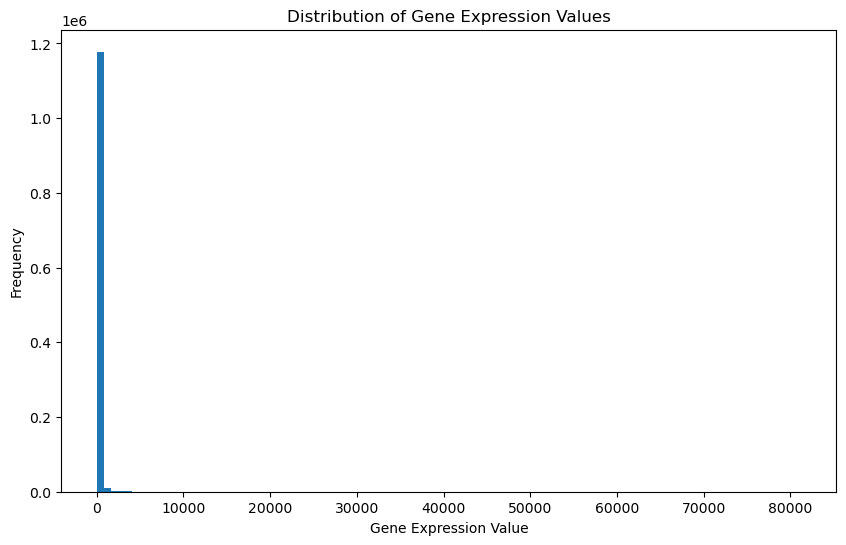

In [1039]:

all_values = x.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(all_values, bins=100)

plt.xlabel("Gene Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [1040]:
x = np.log2(x + 1)
x.head()

,A2M,AAAS,AADAT,AARS1,ABAT,ABCA1,ABCA2,ABCA3,ABCA4,ABCA5,...,ZNF292,ZNF365,ZNF639,ZNF707,ZNFX1,ZNRF4,ZPBP,ZW10,ZWINT,ZYX
0,8.994353,4.584963,3.459432,5.614710,6.643856,5.523562,4.954196,5.209453,0.0,2.321928,...,3.906891,2.584963,3.906891,1.584963,4.523562,0.0,0.0,4.459432,4.392317,5.426265
1,9.134426,5.169925,2.807355,6.303781,6.906891,6.714246,5.209453,6.266787,0.0,3.807355,...,4.584963,2.584963,4.321928,2.584963,6.044394,0.0,0.0,4.807355,3.584963,6.741467
2,8.098032,5.554589,3.459432,5.523562,6.339850,8.092757,6.569856,6.000000,0.0,1.584963,...,5.392317,2.807355,4.087463,3.000000,5.129283,0.0,0.0,5.321928,6.807355,5.584963
3,12.007728,4.169925,1.584963,5.584963,3.169925,7.475733,4.321928,4.459432,1.0,1.000000,...,3.169925,1.584963,2.807355,2.000000,5.523562,0.0,0.0,3.906891,4.392317,6.475733
4,8.700440,4.247928,1.584963,5.169925,5.857981,6.169925,5.169925,5.392317,0.0,2.000000,...,2.807355,1.000000,2.807355,1.000000,5.285402,0.0,0.0,3.459432,3.700440,5.857981


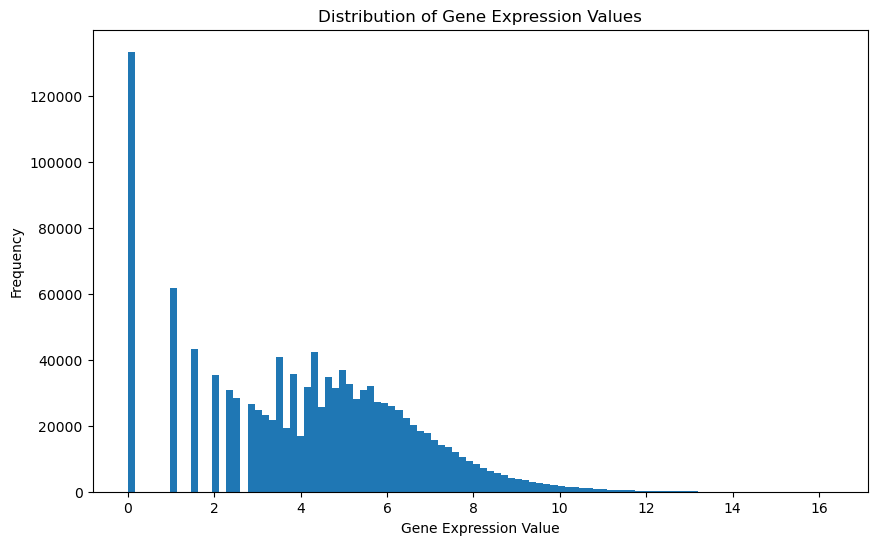

In [1041]:
all_values = x.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(all_values, bins=100)

plt.xlabel("Gene Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [1042]:
scaler = StandardScaler()
x = scaler.fit_transform(x,y)
x = np.round(x, 4)
#change numpy to dataframe
x = pd.DataFrame(x,columns=df.drop(columns=["__label", "__row_index", "CDE_survival_time", "CDE_survival_time_bin", "_PATIENT", "patient_id"]).columns)
print(x.head())

      A2M    AAAS   AADAT   AARS1    ABAT   ABCA1   ABCA2   ABCA3   ABCA4  \
0 -0.2002 -0.5841 -0.0554 -0.6939  0.2800 -0.6447 -0.5751 -0.5827 -0.4332   
1 -0.0857  0.0519 -0.6662  0.1449  0.4869  0.2377 -0.3519  0.3933 -0.4332   
2 -0.9331  0.4701 -0.0554 -0.8049  0.0408  1.2593  0.8380  0.1470 -0.4332   
3  2.2636 -1.0354 -1.8113 -0.7302 -2.4526  0.8020 -1.1281 -1.2751  1.3324   
4 -0.4405 -0.9506 -1.8113 -1.2354 -0.3382 -0.1657 -0.3864 -0.4139 -0.4332   

    ABCA5  ...  ZNF292  ZNF365  ZNF639  ZNF707   ZNFX1   ZNRF4    ZPBP  \
0  0.0091  ... -0.0403 -0.3574 -0.5935 -1.2843 -0.9584 -0.0859 -0.1366   
1  1.4169  ...  0.6061 -0.3574 -0.1570 -0.0101  0.7655 -0.0859 -0.1366   
2 -0.6894  ...  1.3757 -0.1530 -0.4036  0.5188 -0.2718 -0.0859 -0.1366   
3 -1.2438  ... -0.7429 -1.2765 -1.7499 -0.7554  0.1751 -0.0859 -0.1366   
4 -0.2960  ... -1.0885 -1.8142 -1.7499 -2.0296 -0.0948 -0.0859 -0.1366   

     ZW10   ZWINT     ZYX  
0 -0.2334 -0.2241 -1.2832  
1  0.1677 -0.8805 -0.4434  
2  0.760

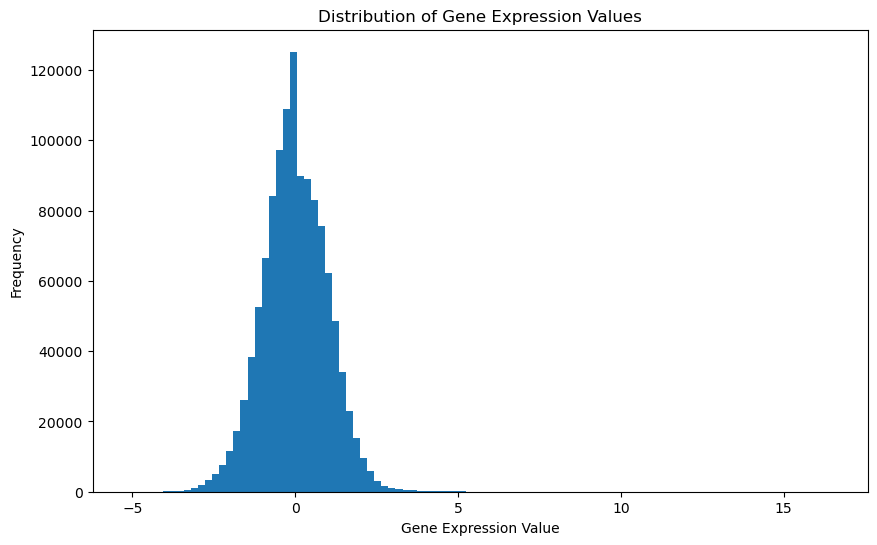

In [1043]:
all_values = x.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(all_values, bins=100)

plt.xlabel("Gene Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [1044]:
x.to_csv("/home/licongcong/Desktop/TCGA/dbeaver/temp/x_dataset.csv", index=False)
y.to_csv("/home/licongcong/Desktop/TCGA/dbeaver/temp/y_dataset.csv", index=False)

In [1045]:
x = x.values
y = y.values
y.shape

(273,)

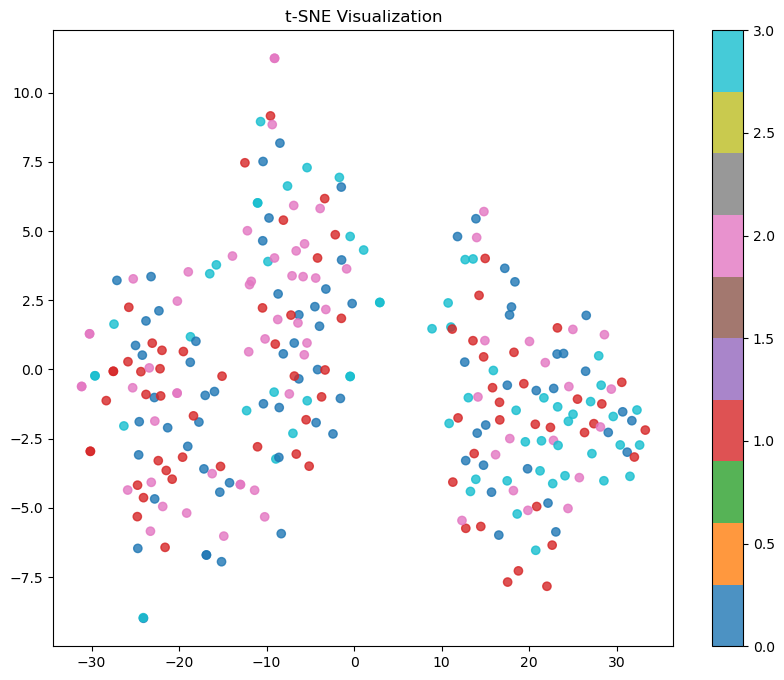

In [1046]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(x)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='tab10',
    alpha=0.8
)

plt.title("t-SNE Visualization")

plt.colorbar(scatter)

plt.show()

In [1047]:
X_train, X_test, y_train, y_test = train_test_split(X_tsne, y,test_size = 0.2, random_state=42)
print(
    np.unique(y_train, return_counts=True),
    np.unique(y_test, return_counts=True)
)

svm_model = SVC(kernel="rbf", C=1, gamma=0.5)
svm_model.fit(X_train, y_train)
y_train_pred = svm_model.predict(X_train)
y_test_pred= svm_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"train acc: {train_acc:.4f}, test acc: {test_acc:.4f}")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_test_pred))

(array([0, 1, 2, 3]), array([58, 58, 55, 47])) (array([0, 1, 2, 3]), array([17, 14, 11, 13]))
train acc: 0.8670, test acc: 0.2545
--- Confusion Matrix ---
[[4 7 1 5]
 [2 6 4 2]
 [5 3 2 1]
 [3 6 2 2]]


In [1048]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train).squeeze()
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test).squeeze()

print(X_train_t.shape, y_train_t.shape, X_test_t.shape, y_test_t.shape)

torch.Size([218, 2]) torch.Size([218]) torch.Size([55, 2]) torch.Size([55])


In [1049]:
X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_test_t = X_test_t.to(device)
y_test_t = y_test_t.to(device)

class MLP(nn.Module):
    def __init__(
        self,
        input_dim,
        n_classes=4,
        projection_dim=128,
        dropout=0.3
    ):
        super(MLP, self).__init__()

        hidden_dim = projection_dim // 2
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.to_logits = nn.Linear(
            hidden_dim,
            n_classes
        )

    def forward(self, x):
        projection = self.net(x)
        logits = self.to_logits(projection)
        return logits

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.softmax(logits, dim=1)
        return probs
    
model = MLP(input_dim=X_train_t.shape[1])
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

for epoch in range(50):
    # --- TRAINING PHASE ---
    model.train()
    optimizer.zero_grad()
    model = model.to(device)
    
    train_outputs = model(X_train_t)
    train_loss = criterion(train_outputs, y_train_t)
    
    train_loss.backward()
    
    nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )
    optimizer.step()
    
    _, train_preds = torch.max(train_outputs, dim=1)
    train_acc = (train_preds == y_train_t).float().mean()

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)

        val_loss = criterion(logits,y_test_t)
        probs = torch.softmax(logits,dim=1)
        
        test_preds = torch.argmax(probs,dim=1)
        val_acc = (test_preds == y_test_t).float().mean() 


    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"{epoch+1:<10}{"Train ACC ":<15}{train_acc.item():<15.2f}{"Val ACC ":<15}{val_acc.item():<15.2f}{"Train Loss ":<15}{train_loss.item():<15.4f}{"Val Loss ":<15}{val_loss.item():<15.4f}")

print("-" * 70)
print(f"Final Evaluation Complete. Target Validation Accuracy: {val_acc.item():.2f}%")

1         Train ACC      0.28           Val ACC        0.27           Train Loss     1.5051         Val Loss       1.4378         
10        Train ACC      0.28           Val ACC        0.27           Train Loss     1.4135         Val Loss       1.3782         
20        Train ACC      0.35           Val ACC        0.31           Train Loss     1.3498         Val Loss       1.3669         
30        Train ACC      0.29           Val ACC        0.29           Train Loss     1.3571         Val Loss       1.3762         
40        Train ACC      0.36           Val ACC        0.31           Train Loss     1.3333         Val Loss       1.3810         
50        Train ACC      0.35           Val ACC        0.31           Train Loss     1.3376         Val Loss       1.3808         
----------------------------------------------------------------------
Final Evaluation Complete. Target Validation Accuracy: 0.31%


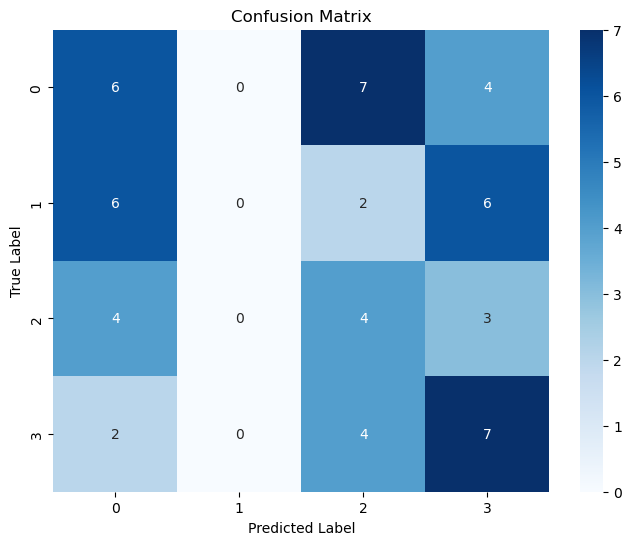

In [1050]:
cm = confusion_matrix(
    y_test_t.detach().cpu().numpy(),
    test_preds.detach().cpu().numpy()
)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [1051]:
mlp = MLPClassifier(solver='lbfgs', random_state=42)
mlp.fit(X_train, y_train)

/home/licongcong/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [1052]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

In [1053]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"train acc: {train_acc:.4f}, test acc: {test_acc:.4f}")

train acc: 0.4541, test acc: 0.2545


In [1054]:
mlp_act = MLPClassifier(activation='tanh', solver='lbfgs', max_iter=5000, random_state=42, batch_size=32, learning_rate_init=0.0001)
mlp_act.fit(X_train, y_train)

/home/licongcong/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,hidden_layer_sizes,"(100,)"
,activation,'tanh'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.0001
,power_t,0.5
,max_iter,5000
,shuffle,True
,random_state,42


In [1055]:
y_train_pred = mlp_act.predict(X_train)
y_test_pred = mlp_act.predict(X_test)

In [1056]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"train acc: {train_acc:.4f}, test acc: {test_acc:.4f}")

train acc: 0.9220, test acc: 0.3636


In [10]:
metadata = pd.read_csv("/home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival/dataset_csv/metadata/clinical_gbm.csv")
print(metadata.shape)
metadata.head()

(629, 16)


,sampleID,CDE_DxAge,CDE_survival_days,CDE_vital_status,_INTEGRATION,_PATIENT,_primary_site,bcr_patient_barcode,bcr_patient_uuid,days_to_death,days_to_last_followup,days_to_new_tumor_event_after_initial_treatment,gender,vital_status,year_of_initial_pathologic_diagnosis,CDE_survival_time
0,TCGA-02-0001-01,44.30,353.0,DECEASED,TCGA-02-0001-01,TCGA-02-0001,Brain,TCGA-02-0001,30a1fe5e-5b12-472c-aa86-c2db8167ab23,358,279.0,137,FEMALE,DECEASED,2002.0,11.766667
1,TCGA-02-0002-01,NaN,NaN,NaN,TCGA-02-0002-01,TCGA-02-0002,Brain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-02-0003-01,50.21,144.0,DECEASED,TCGA-02-0003-01,TCGA-02-0003,Brain,TCGA-02-0003,df3c1d61-79c1-43e9-971a-8029497ffeab,144,144.0,40,MALE,DECEASED,2003.0,4.800000
3,TCGA-02-0004-01,59.18,345.0,DECEASED,TCGA-02-0004-01,TCGA-02-0004,Brain,TCGA-02-0004,3ac8f759-2df0-4ef5-913f-ce05b8dd8937,345,345.0,314,MALE,DECEASED,2002.0,11.500000
4,TCGA-02-0006-01,56.17,558.0,DECEASED,TCGA-02-0006-01,TCGA-02-0006,Brain,TCGA-02-0006,98714d95-b62e-4f34-9cd1-91542da463eb,558,558.0,302,FEMALE,DECEASED,2002.0,18.600000


In [11]:
wsi_metadata = pd.read_csv("/home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival/dataset_csv/wsi_data/wsi_metadata_gbm.csv")
print(wsi_metadata.shape)
wsi_metadata.head()

(860, 4)


,svs_filename,pt_filename,patient_id,status
0,TCGA-27-1835-01Z-00-DX2.213a0703-64a3-4feb-b9c...,TCGA-27-1835-01Z-00-DX2.213a0703-64a3-4feb-b9c...,TCGA-27-1835,tumor
1,TCGA-02-0440-01Z-00-DX1.4fef88c9-eff7-4e00-be1...,TCGA-02-0440-01Z-00-DX1.4fef88c9-eff7-4e00-be1...,TCGA-02-0440,tumor
2,TCGA-12-0819-01Z-00-DX2.CA37F7BE-86D9-421F-B5A...,TCGA-12-0819-01Z-00-DX2.CA37F7BE-86D9-421F-B5A...,TCGA-12-0819,tumor
3,TCGA-12-0819-01Z-00-DX3.F5692549-B432-435C-A20...,TCGA-12-0819-01Z-00-DX3.F5692549-B432-435C-A20...,TCGA-12-0819,tumor
4,TCGA-26-6174-01Z-00-DX1.D5C87A05-8A2E-4108-99D...,TCGA-26-6174-01Z-00-DX1.D5C87A05-8A2E-4108-99D...,TCGA-26-6174,tumor


In [ ]:
df_m = pd.merge(metadata, wsi_metadata, left_on="_PATIENT", right_on="patient_id", how="inner", columns=["patient_id", "CDE_survival_time", "CDE_survival_time_bin", "__label"])
print(df_m.shape)
df_m.head()

(899, 20)


,sampleID,CDE_DxAge,CDE_survival_days,CDE_vital_status,_INTEGRATION,_PATIENT,_primary_site,bcr_patient_barcode,bcr_patient_uuid,days_to_death,days_to_last_followup,days_to_new_tumor_event_after_initial_treatment,gender,vital_status,year_of_initial_pathologic_diagnosis,CDE_survival_time,svs_filename,pt_filename,patient_id,status
0,TCGA-02-0001-01,44.30,353.0,DECEASED,TCGA-02-0001-01,TCGA-02-0001,Brain,TCGA-02-0001,30a1fe5e-5b12-472c-aa86-c2db8167ab23,358,279.0,137,FEMALE,DECEASED,2002.0,11.766667,TCGA-02-0001-01Z-00-DX1.83fce43e-42ac-4dcd-b15...,TCGA-02-0001-01Z-00-DX1.83fce43e-42ac-4dcd-b15...,TCGA-02-0001,tumor
1,TCGA-02-0001-01,44.30,353.0,DECEASED,TCGA-02-0001-01,TCGA-02-0001,Brain,TCGA-02-0001,30a1fe5e-5b12-472c-aa86-c2db8167ab23,358,279.0,137,FEMALE,DECEASED,2002.0,11.766667,TCGA-02-0001-01Z-00-DX3.2836ce55-491f-4d86-99b...,TCGA-02-0001-01Z-00-DX3.2836ce55-491f-4d86-99b...,TCGA-02-0001,tumor
2,TCGA-02-0001-01,44.30,353.0,DECEASED,TCGA-02-0001-01,TCGA-02-0001,Brain,TCGA-02-0001,30a1fe5e-5b12-472c-aa86-c2db8167ab23,358,279.0,137,FEMALE,DECEASED,2002.0,11.766667,TCGA-02-0001-01Z-00-DX2.b521a862-280c-4251-ab5...,TCGA-02-0001-01Z-00-DX2.b521a862-280c-4251-ab5...,TCGA-02-0001,tumor
3,TCGA-02-0003-01,50.21,144.0,DECEASED,TCGA-02-0003-01,TCGA-02-0003,Brain,TCGA-02-0003,df3c1d61-79c1-43e9-971a-8029497ffeab,144,144.0,40,MALE,DECEASED,2003.0,4.800000,TCGA-02-0003-01Z-00-DX3.995C2924-E298-4517-82A...,TCGA-02-0003-01Z-00-DX3.995C2924-E298-4517-82A...,TCGA-02-0003,tumor
4,TCGA-02-0003-01,50.21,144.0,DECEASED,TCGA-02-0003-01,TCGA-02-0003,Brain,TCGA-02-0003,df3c1d61-79c1-43e9-971a-8029497ffeab,144,144.0,40,MALE,DECEASED,2003.0,4.800000,TCGA-02-0003-01Z-00-DX1.6171b175-0972-4e84-999...,TCGA-02-0003-01Z-00-DX1.6171b175-0972-4e84-999...,TCGA-02-0003,tumor


In [17]:
df_m.to_csv("/home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival/dataset_csv/temp.csv", index=False)